In [1]:
# Leer archivo

import pandas as pd

df = pd.read_csv('Advertising.csv')

df.head() # Primeras n líneas del DataFrame

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [2]:
df.tail() # Últimas n líneas del DataFrame

,Unnamed: 0,TV,radio,newspaper,sales
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5
199,200,232.1,8.6,8.7,13.4


In [3]:
df.describe() # Estadísticas descriptivas del DataFrame

,Unnamed: 0,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [4]:
df.shape[0] # Número de filas del DataFrame
df.shape[1] # Número de columnas del DataFrame

print("Número de filas:", df.shape[0])
print("Número de columnas:", df.shape[1])

Número de filas: 200
Número de columnas: 5


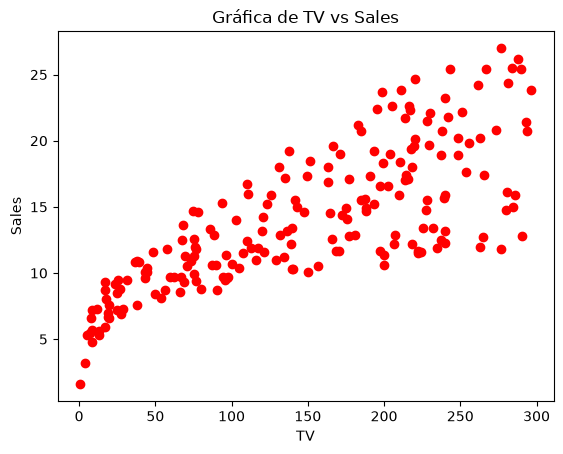

In [5]:
# Gráfica de TV vs Sales

import matplotlib.pyplot as plt

plt.scatter(df['TV'], df['sales'], color='red')
plt.xlabel('TV')
plt.ylabel('Sales')
plt.title('Gráfica de TV vs Sales')
plt.show()

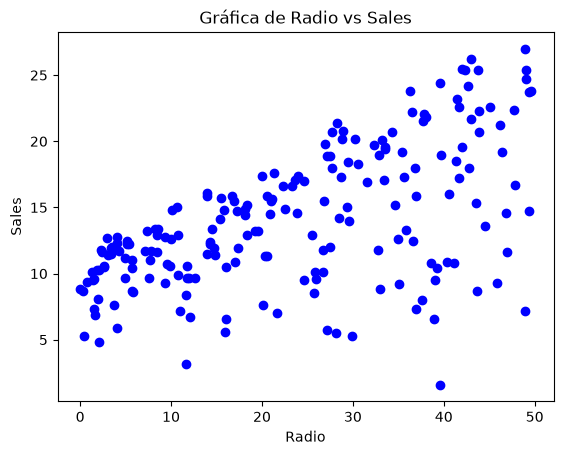

In [6]:
# Gráfica de Radio vs Sales
plt.scatter(df['radio'], df['sales'], color='blue')
plt.xlabel('Radio')
plt.ylabel('Sales')
plt.title('Gráfica de Radio vs Sales')
plt.show()


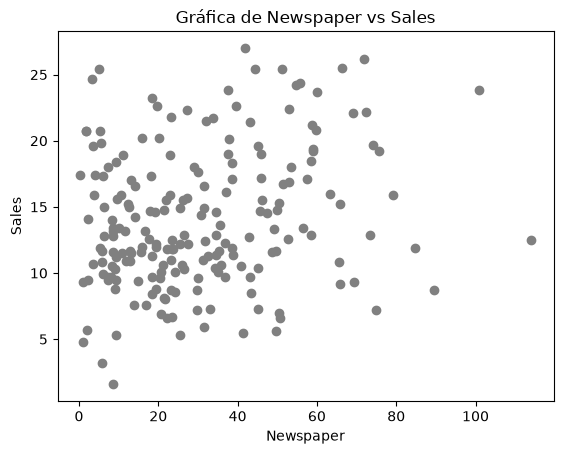

In [7]:
# Gráfica de Newspaper vs Sales
plt.scatter(df['newspaper'], df['sales'], color='grey')
plt.xlabel('Newspaper')
plt.ylabel('Sales')
plt.title('Gráfica de Newspaper vs Sales')
plt.show()


In [8]:
# Modelo de regresión sales ~ B0 + B1*TV

import numpy as np
from sklearn.linear_model import LinearRegression

x_v = df['TV'].values.reshape(-1, 1) # Variable independiente
y_v = df['sales'].values.reshape(-1, 1) # Variable dependiente

# Crear el modelo de regresión lineal

model = LinearRegression()
model.fit(x_v, y_v)

# Coeficientes del modelo
b0 = model.intercept_[0] # Intercepto
b1 = model.coef_[0][0] # Coeficiente de la variable independiente

print(f"Modelo de regresión: sales = {b0:.6f} + {b1:.6f}*TV")

Modelo de regresión: sales = 7.032594 + 0.047537*TV


In [9]:
# Calcular error de forma analítica, el error estándar del intercepto y el error estándar del coeficiente de la variable independiente

# Para el intercepto
n = len(x_v) # Número de observaciones
x_bar = np.mean(x_v) # Media de la variable independiente
x_dis = df["TV"] - x_bar
x_dis = x_dis ** 2
x_dis = np.sum(x_dis)
E = df["sales"] - (b0 + b1 * df["TV"])
E = E ** 2
E = np.sum(E)
RSS = E # Residual sum of squares
sigma2 = (RSS / (n - 2)) # Varianza de los errores
SE_B02 = sigma2 * (1/n + x_bar**2 / x_dis) # Error estándar del intercepto
SE_B0 = np.sqrt(SE_B02)

print(f"Error estándar del intercepto: {SE_B0:.6f}")

# Para el coeficiente de la variable independiente

SE_B12 = sigma2 / (x_dis) # Error estándar del coeficiente de la variable independiente
SE_B1 = np.sqrt(SE_B12)

print(f"Error estándar del coeficiente: {SE_B1:.6f}")



Error estándar del intercepto: 0.457843
Error estándar del coeficiente: 0.002691


In [10]:
# H0: No hay relación entre TV y sales.
# H1: B1 |= 0

from scipy import stats

t_statistic = b1 / SE_B1 # Estadístico t
p_value = 2 * (1 - stats.t.cdf(np.abs(t_statistic), n - 5)) # Valor p

print(f"Estadístico t: {t_statistic:.6f}")
print(f"Valor p: {p_value:.10f}")

Estadístico t: 17.667626
Valor p: 0.0000000000
